In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import ipywidgets as w
from IPython.display import clear_output
from io import StringIO


data = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-04-17.1.csv')
area = np.zeros((1600, 1600))

scaling = 4 / 2.0

x = lambda r: int(((r + scaling)/(scaling * 2)) * 1599)
y = lambda i: int(((i + scaling)/(scaling * 2)) * 1599)

for idx, row in data.iterrows():
    area[x(row['r'])][y(row['i'])] = row['value']

fig = plt.figure()
fig.set_size_inches(12, 12)
ax = fig.add_subplot(1, 1, 1)
# # ax.get_figure().set_size_inches(7, 7)
# ax.spines['left'].set_position('center')
# ax.spines['bottom'].set_position('center')
# ax.spines['top'].set_color('none')
# ax.spines['right'].set_color('none')

ax.set_axis_off()
# ax.grid(linestyle='dotted')
# ax.locator_params(axis='x', nbins = 4)
# ax.locator_params(axis='y', nbins = 4)

plt.imshow(area.T, cmap = plt.colormaps['BuPu_r'])
plt.show()

# def run(b):
#     global uploader
#     render(pd.read_csv(StringIO("csv string")))

# uploader = w.FileUpload(multiple=False)
# # t = w.Text()
# run_button = w.Button(description='Run', icon='play')
# run_button.on_click(run)
# h_box = w.HBox([uploader, run_button])
# display(h_box)

ModuleNotFoundError: No module named 'secrets'

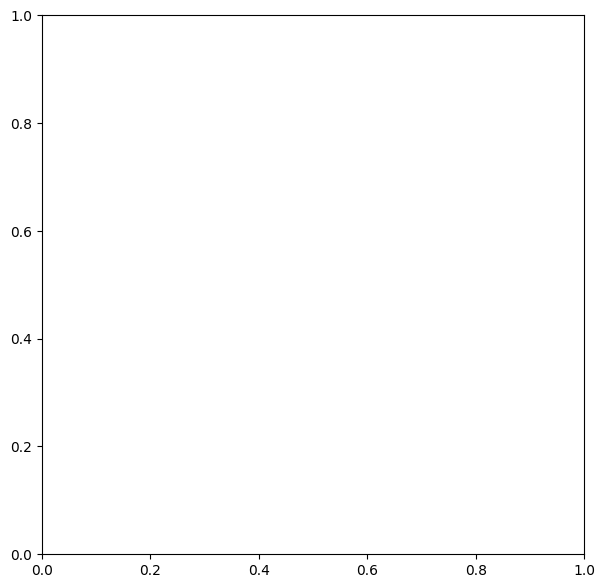

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as colors
from concurrent.futures import ThreadPoolExecutor, Future

executor = ThreadPoolExecutor(max_workers=None)

# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-03-27.csv')
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-03-27-1.csv')
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-06.1.csv')
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-13.3.csv') # deep zoom w. structure
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-18.2.csv') # too deep a zoom (blank field after an hour!)
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-20.1.csv') # zoom = 150_000 work-3.yml
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-22.1.csv')
ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-22.2.csv')

def plotDs(ax: plt.Axes, ds: pd.DataFrame):
    ball = (1001, 1001)
    space = np.zeros(ball)

    df = ds.sort_values(['i', 'r'], ascending=True)
    # print(df.iloc[500000, :])

    # annotation_point = None
    # annotation_coords = -0.19821982198219823-1.1003100310031004j
    # annotation_ball = 1e-2
    # print(df.head())

    # Plotting by transforming coordinates
    min_r, max_r = np.min(df["r"]), np.max(df["r"])
    min_i, max_i = np.min(df["i"]), np.max(df["i"])

    conv_r = lambda x: ((ball[0] - 1) * (x - min_r)) / (max_r - min_r)
    conv_i = lambda x: ((ball[1] - 1) * (x - min_i)) / (max_i - min_i)

    # print(df.head())

    # scale = 10
    for entry in df.iterrows():
        # executor.submit(process, entry, conv_r, conv_i).add_done_callback(assignSpace)

        if (np.isnan(entry[1].r) or np.isnan(entry[1].i)):
            continue
        x, y = int(np.round(conv_r(entry[1].r))), int(np.round(conv_i(entry[1].i)))
        space[y][x] = entry[1].value % 200
        # y = np.abs(min_i) + entry[1].i
    print('----')
    # print(space[100][100])

    # # ax.get_figure().set_size_inches(7, 7)
    # ax.spines['left'].set_position('center')
    # ax.spines['bottom'].set_position('center')
    # ax.spines['top'].set_color('none')
    # ax.spines['right'].set_color('none')
    # print(annotation_point)
    ax.grid(linestyle='dotted')
    ax.locator_params(axis='x', nbins = 4)
    ax.locator_params(axis='y', nbins = 4)

    # ax.annotate('x', xy=annotation_point)
    ax.set_axis_off()
    ax.imshow(space, cmap = 'BuPu')

fig = plt.figure()

fig.set_size_inches(7, 7)
ax = fig.add_subplot(1, 1, 1)

# plotDs(ax, ds)

# cmap = colors.LinearSegmentedColormap.from_list('a', plt.get_cmap('bone_r')(np.linspace(.2, .4, 1000)))
# cmap = colors.LinearSegmentedColormap.from_list()

# plt.imshow(space, cmap = 'BuPu')#, norm=colors.Normalize(vmin=-1, vmax=5000))
#plt.show()


## Continuous Wavelet Transform of Signal Data

/Users/rodericktimmerman/workspace/testbed/.venv/lib/python3.13/site-packages/matplotlib/contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
/Users/rodericktimmerman/workspace/testbed/.venv/lib/python3.13/site-packages/matplotlib/contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
/Users/rodericktimmerman/workspace/testbed/.venv/lib/python3.13/site-packages/numpy/ma/core.py:2892: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


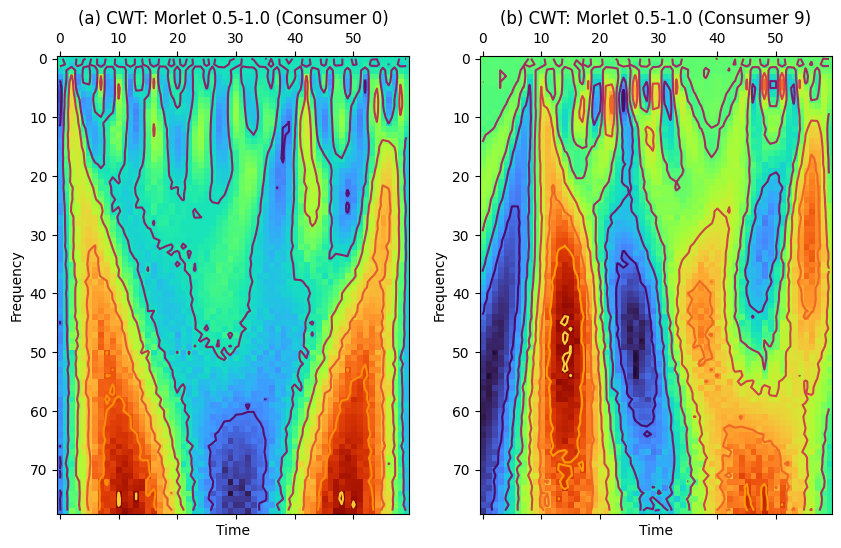

In [159]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt

perfData = pd.read_csv('./Dwell Time-data-as-joinbyfield-2025-05-27 16_52_09.csv')
# coef, freq = pywt.cwt(perfData['{group="consumers-custom", instance="consumer-9:9180", job="experiment"}'][1200:1400], scales = np.arange(1, 50,.3), wavelet='morl')
data_region = perfData['{group="consumers-custom", instance="consumer-0:9180", job="experiment"}'][1217:1277]
data_region2 = perfData['{group="consumers-custom", instance="consumer-9:9180", job="experiment"}'][1217:1277]
coef, freq = pywt.cwt(data_region, scales = np.arange(1, 40,.5), wavelet='cmor0.5-1.0')
coef2, freq2 = pywt.cwt(data_region2, scales = np.arange(1, 40,.5), wavelet='cmor0.5-1.0')

# plt.plot(perfData['{group="consumers-custom", instance="consumer-9:9180", job="experiment"}'])
# plt.pcolormesh(coef, cmap='BuPu_r')
fig, [ax1, ax2]= plt.subplots(1, 2)
# fig.suptitle('Wavelet Analysis')
fig.set_size_inches(10, 7)
# ax1 = fig.add_subplot(1, 1, 1)
ax1.set_xlabel('Time')
ax1.set_ylabel('Frequency')
ax1.set_title('(a) CWT: Morlet 0.5-1.0 (Consumer 0)')
ax1.matshow(coef.real, cmap='turbo')
ax1.contour(coef, cmap='inferno')

ax2.set_xlabel('Time')
ax2.set_ylabel('Frequency')
ax2.set_title('(b) CWT: Morlet 0.5-1.0 (Consumer 9)')
ax2.matshow(coef2.real, cmap='turbo')
ax2.contour(coef2, cmap='inferno')

# ax.invert_yaxis()
plt.show()

# plt.contour(coef, cmap='BuPu_r')


/Users/rodericktimmerman/workspace/testbed/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/rodericktimmerman/workspace/testbed/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Data FFT')

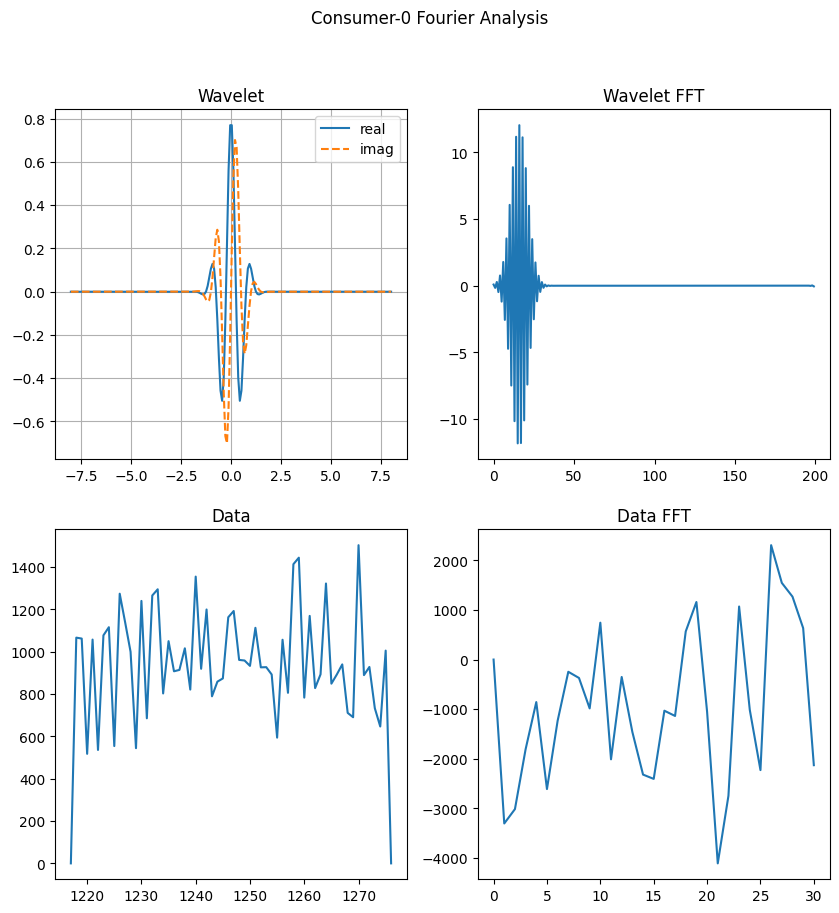

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# wavelet = pywt.ContinuousWavelet("cmor1.5-1.0")
wavelet = pywt.ContinuousWavelet("cmor0.5-1.0")
# wavelet = pywt.Wavelet('haar')

total_points = 200
psi, x = wavelet.wavefun(level=8, length=total_points)
fft = np.fft.fft(psi)
fig, ((plt1, plt2), (plt3, plt4)) = plt.subplots(2, 2)
fig.set_size_inches(10, 10)
fig.suptitle('Consumer-0 Fourier Analysis')
# plt1.figure(figsize=(10, 4))
plt1.plot(x, np.real(psi), label="real")
plt1.plot(x, np.imag(psi), label="imag", linestyle='--')
# plt1.title('Morlet (cmor) Wavelet')
# plt1.xlabel('Time')
# plt1.ylabel('Amplitude')
plt1.set_title('Wavelet')
plt1.legend()
plt1.grid(True)

plt2.plot(fft)
plt2.set_title('Wavelet FFT')

data = perfData[1217:1277]['{group="consumers-custom", instance="consumer-0:9180", job="experiment"}']
perfdata_fft = np.fft.rfft(data - np.mean(data)) # rfft removes symetries from a regular fft plot.

plt3.plot(data)
plt3.set_title('Data')

plt4.plot(perfdata_fft)
plt4.set_title('Data FFT')



## Grand Tour Data Analysis
What follows the generation of subplots \[from the grand tour dataset\].

all threads have started...
----
thread t1 completed
----
thread t3 completed
----
thread t2 completed
done.


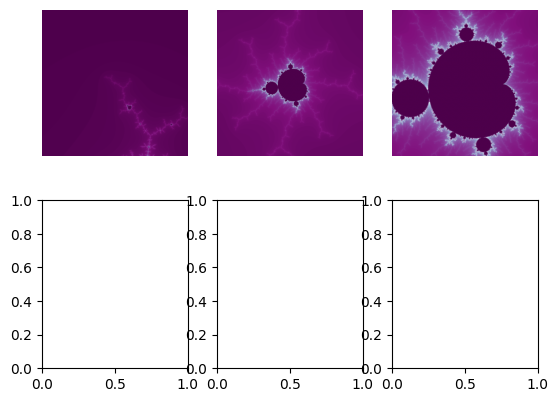

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import threading

# try:
#     ds1.head()
#     ds2.head()
#     ds3.head()
# except NameError:
ds1 = ds2 = d3 = None
ds1, ds2, ds3 = [
    pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/grandtour-data-20250529/run0-02b3c839-437d-4180-9e06-6577d5b3b4c9.csv'),        
    pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/grandtour-data-20250529/run0-8696741f-cfa1-4c0c-9172-d2a38d81a5fe.csv'),
    pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/grandtour-data-20250529/run0-57fc3e5e-4796-4109-b30d-7512f090d211.csv'),        
]
fig, ax = plt.subplots(2,3)

threads = [
    threading.Thread(target=lambda ax, ds: plotDs(ax, ds), args=(ax[0][0], ds1),name="t1"),
    threading.Thread(target=lambda ax, ds: plotDs(ax, ds), args=(ax[0][2], ds3),name="t3"),
    threading.Thread(target=lambda ax, ds: plotDs(ax, ds), args=(ax[0][1], ds2),name="t2"),
]

for t in threads:
    t.start()
print("all threads have started...")
for t in threads:
    t.join()
    print(f"thread {t.name} completed")
print("done.")

# plotDs(ax[0][0], ds1)
# plotDs(ax[0][1], ds2)
# plotDs(ax[0][2], ds3)


[Text(0, 0, 'consumer-0'),
 Text(1, 0, 'consumer-1'),
 Text(2, 0, 'consumer-2'),
 Text(3, 0, 'consumer-3'),
 Text(4, 0, 'consumer-4'),
 Text(5, 0, 'consumer-5'),
 Text(6, 0, 'consumer-6'),
 Text(7, 0, 'consumer-7'),
 Text(8, 0, 'consumer-8'),
 Text(9, 0, 'consumer-9'),
 Text(10, 0, 'consumer-10'),
 Text(11, 0, 'consumer-11'),
 Text(12, 0, 'consumer-12'),
 Text(13, 0, 'consumer-13'),
 Text(14, 0, 'consumer-14'),
 Text(15, 0, 'consumer-15')]

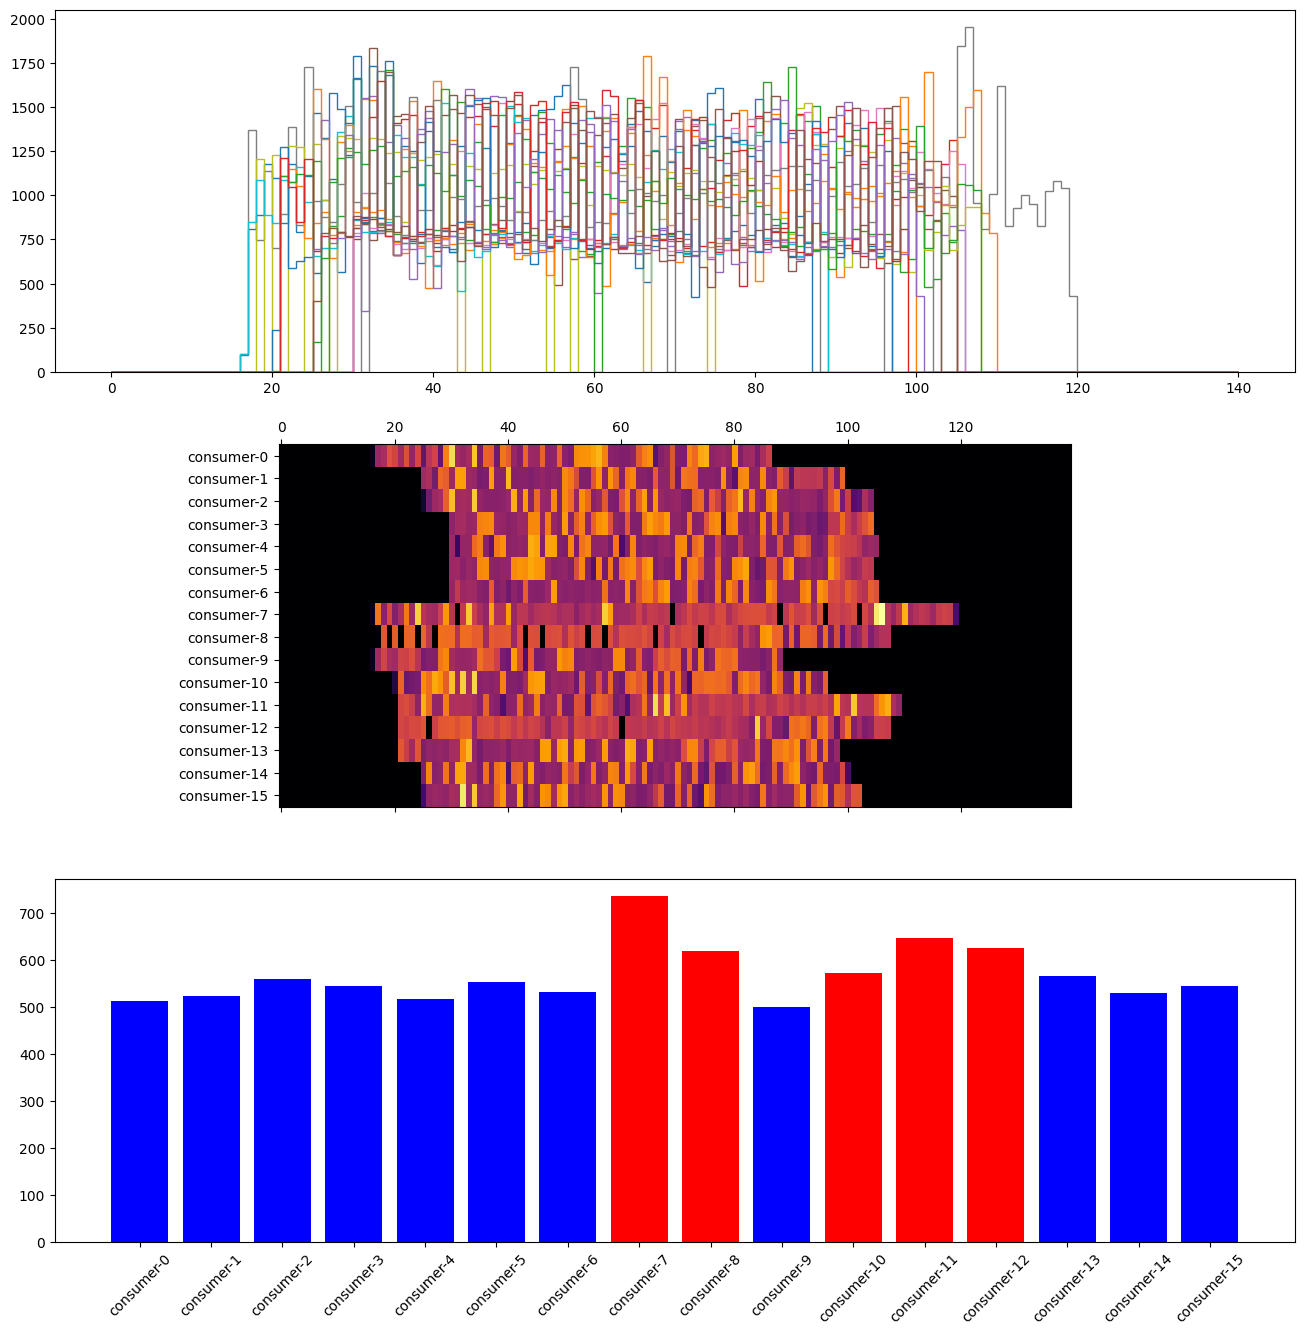

In [249]:
import matplotlib.pyplot as plt
import pandas as pd
gtData = pd.read_csv('./Dwell Time-data-as-joinbyfield-2025-05-27 16_52_09.csv')
fig = plt.figure()
fig.set_size_inches(16, 16)
ax = fig.subplots(3, 1)

lh, rh = 120, 260
t = slice(gtData['Time'], lh, rh)
runs = []
means = []
for c in filter(lambda name: name not in ('Time'), gtData.columns):
    run = gtData[c][lh:rh]
    means.append(run.mean())
    runs.append(run)
    ax[0].stairs(run)
ax[1].matshow(runs, cmap='inferno', aspect=4.0)
ax[1].set_yticks(range(0, 16))
ax[1].set_yticklabels(map(lambda n: f"consumer-{n}", range(0, 16)))

sd = np.mean(means)
mcol = [{m > sd: 'red', m <= sd: 'blue'}[True] for m in means]
ax[2].bar(range(0, len(means)), means, color=mcol)
ax[2].set_xticks(range(0, 16))
ax[2].set_xticklabels(map(lambda n: f"consumer-{n}", range(0, 16)), rotation=45)


midway for test-0 = (-0.19871950000000002-1.099977j)
midway for test-1 = (-0.19838650000000002-1.099977j)
midway for test-2 = (-0.198053-1.099977j)
midway for test-3 = (-0.19771950000000002-1.099977j)
midway for test-4 = (-0.19871950000000002-1.10031j)
midway for test-5 = (-0.19838650000000002-1.10031j)
midway for test-6 = (-0.198053-1.10031j)
midway for test-7 = (-0.19771950000000002-1.10031j)
midway for test-8 = (-0.19871950000000002-1.100643j)
midway for test-9 = (-0.19838650000000002-1.100643j)
midway for test-10 = (-0.198053-1.100643j)
midway for test-11 = (-0.19771950000000002-1.100643j)
midway for test-12 = (-0.19871950000000002-1.100977j)
midway for test-13 = (-0.19838650000000002-1.100977j)
midway for test-14 = (-0.198053-1.100977j)
midway for test-15 = (-0.19771950000000002-1.100977j)


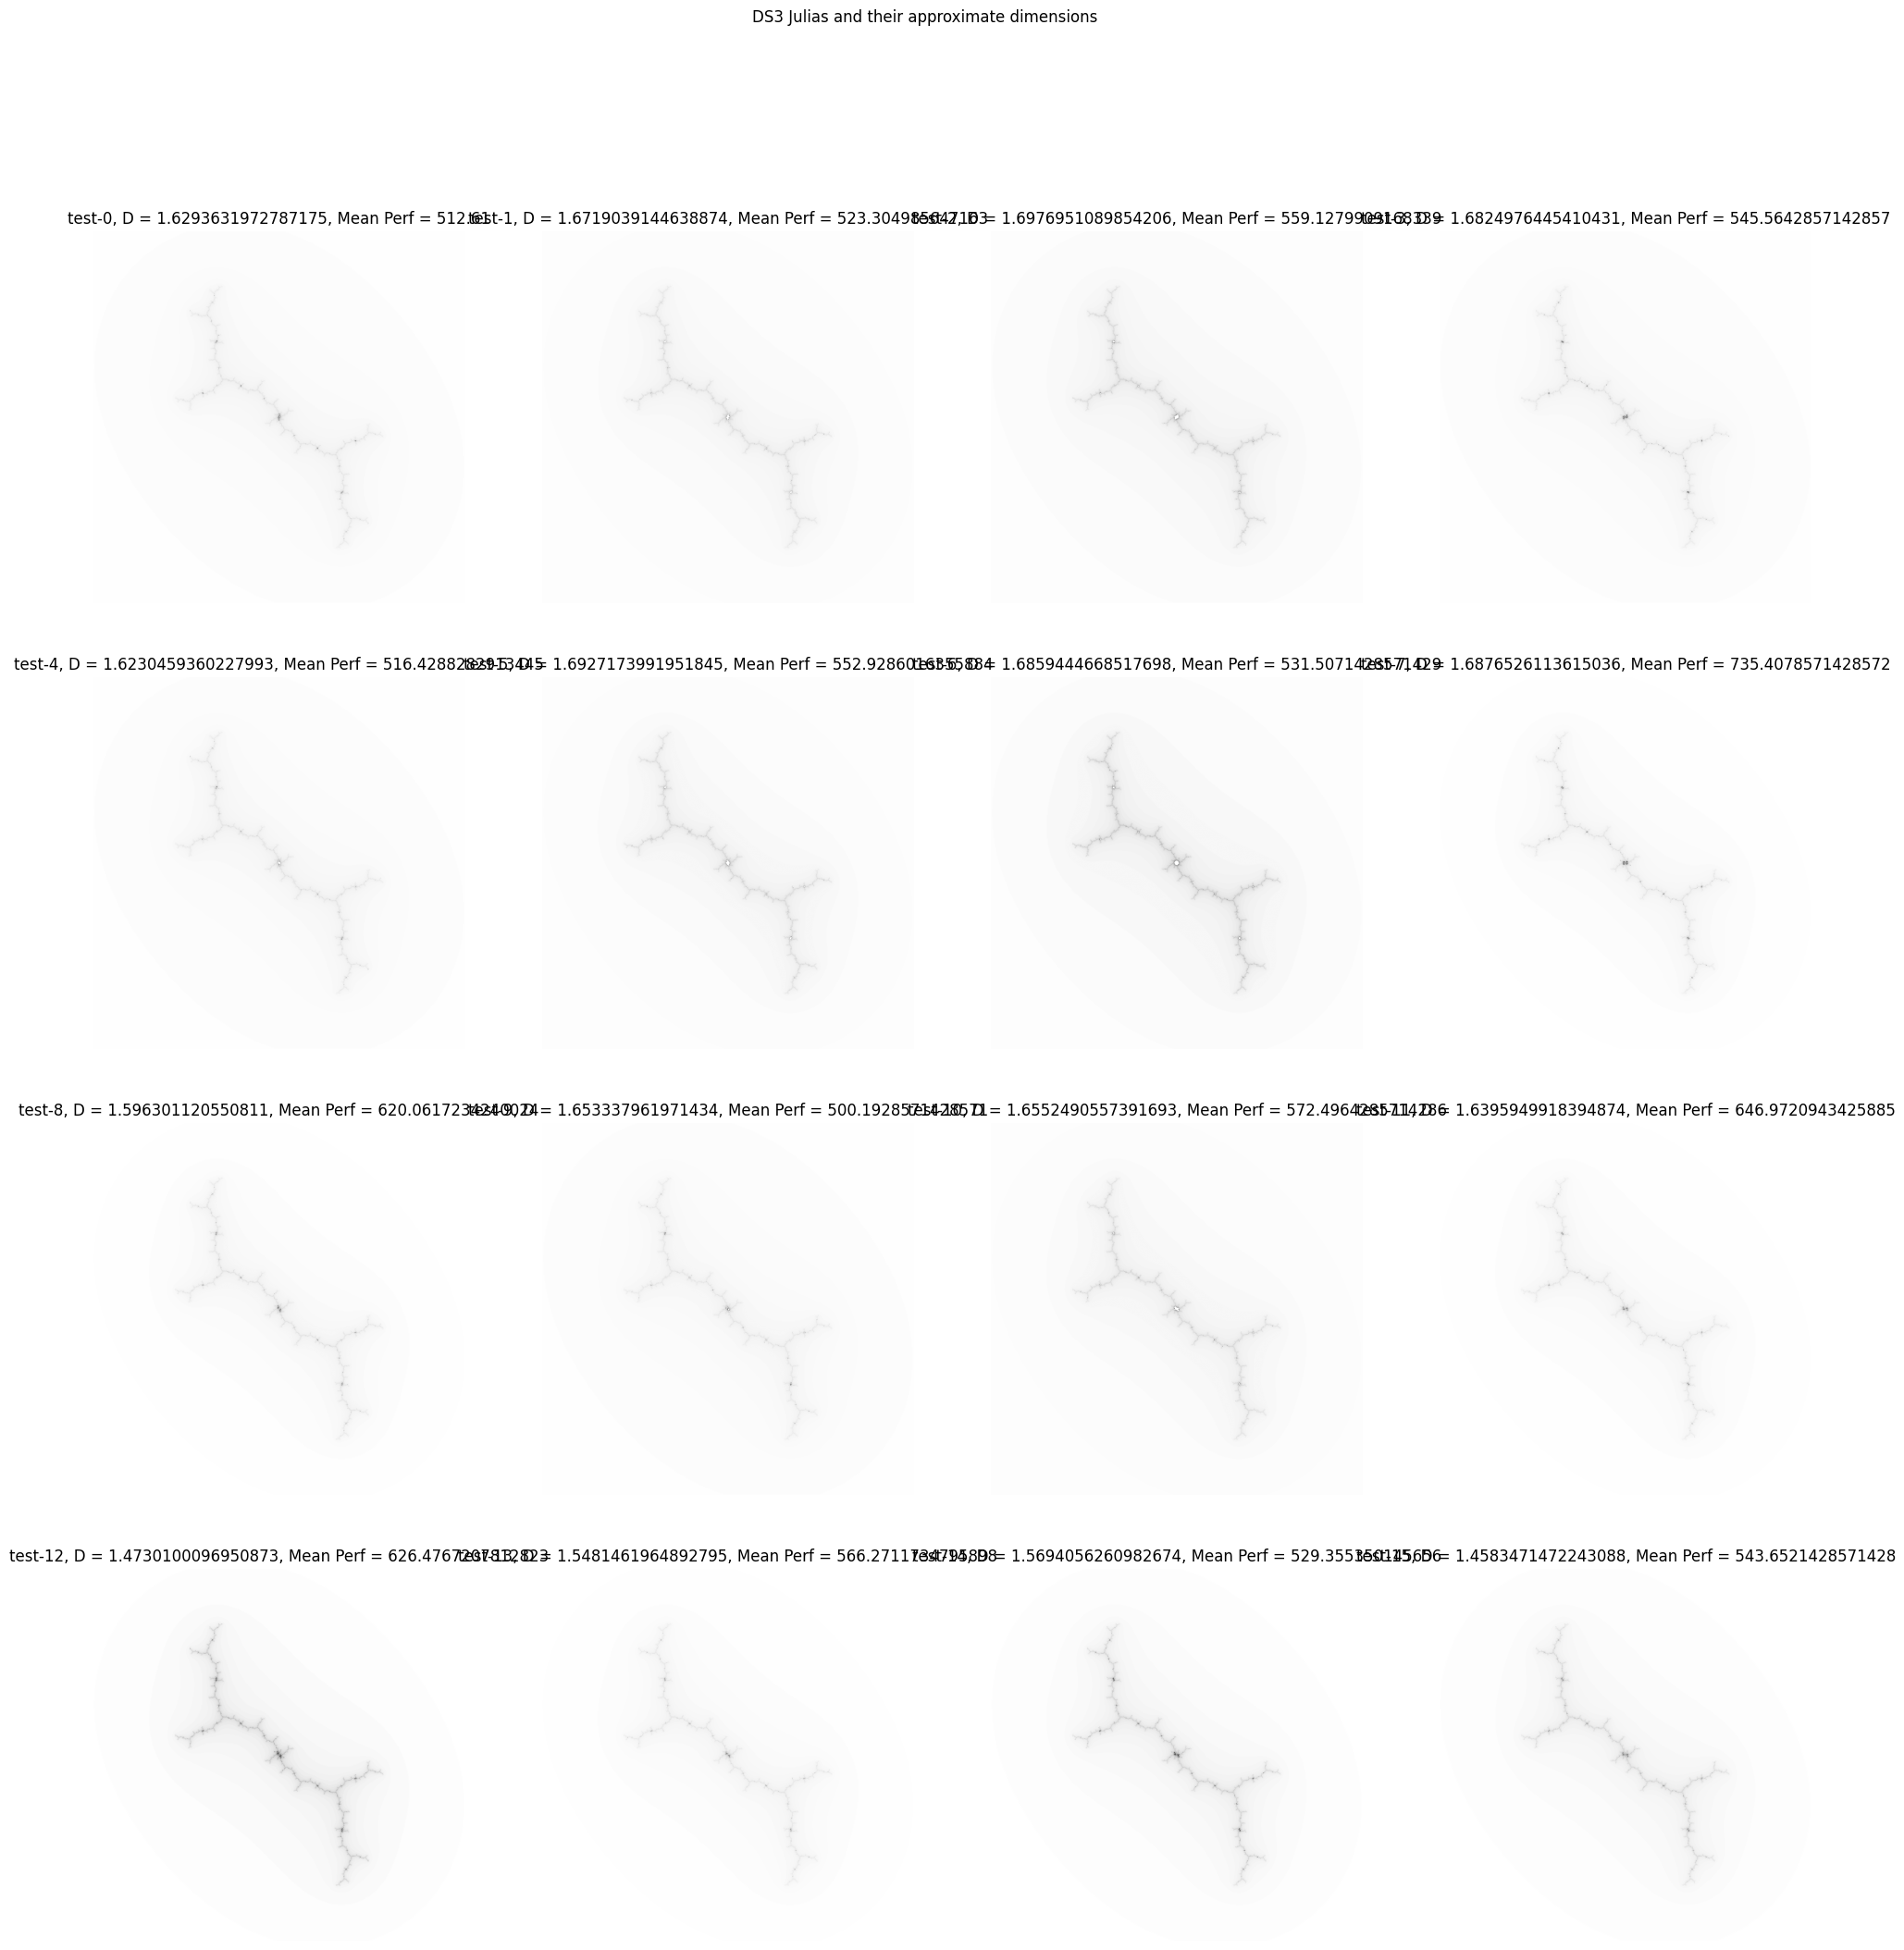

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
def plot_julia(ds: pd.DataFrame, topic: str, ax: plt.Axes, mean=None):
    t0 = ds.loc[lambda df: df.fromTopic == topic]
    np.min(t0.r)
    np.min(t0.i)
    lh, rh = np.complex128(np.min(t0.r), np.min(t0.i)), np.complex128(np.max(t0.r), np.min(t0.i))
    # lh, rh = np.sum(t0.r), np.median(t0.i)
    #t0.r.count()


    interval = np.abs(lh - rh) / t0.r.count()

    midway = lh + (interval / 2) * t0.r.count()
    print(f"midway for {topic} = {midway}")

    area = np.zeros((1001, 1001))

    bounds_r = np.linspace(-2, 2, 1000)
    bounds_i = np.linspace(-2, 2, 1000)

    r, i = np.meshgrid(bounds_r, bounds_i)
    grid = r + 1j * i

    blowup = 4.0
    box_threshold = 30
    nr = 0
    for z in grid.flatten():
        m = z
        x = ((2 + z.real) / 4) * 1000
        y = ((2 + z.imag) / 4) * 1000
        for iteration in range(0, 100):
            m = np.pow(m, 2) + midway
            if (np.abs(m) >= blowup):
                area[int(x)][int(y)] = iteration
                break
            area[int(x)][int(y)] = -1
        if (box_threshold <= area[int(x)][int(y)] or area[int(x)][int(y)] == -1):
            nr += 1

    dimension = np.log(nr)/np.log(np.sqrt(1000)) 

    plt3 = plt.figure()
    ax.imshow(area, cmap='Greys')
    mean_text = {True: f", Mean Perf = {mean}", False: ""}[mean != None]
    ax.set_title(f"{topic}, D = {dimension}{mean_text}")
    ax.set_axis_off()

# Generate Gallery of Julia Sets and box counts
fig = plt.figure()
fig.set_size_inches(24, 24)
fig.suptitle('DS3 Julias and their approximate dimensions')
ax = fig.subplots(4, 4)
for x in range(0, 4):
    for y in range(0, 4):
        # Plot julia set
        try:
            plot_julia(ds3, f"test-{(4 * x) + y}", ax[x][y], np.round(means[(4 * x) + y], 2))
        except NameError:
            plot_julia(ds3, f"test-{(4 * x) + y}", ax[x][y])
        # Box count algorihtm
        



### Performance Evaluation for Gran Rtour.